Generated dataset file.
readings: (1130, 6)


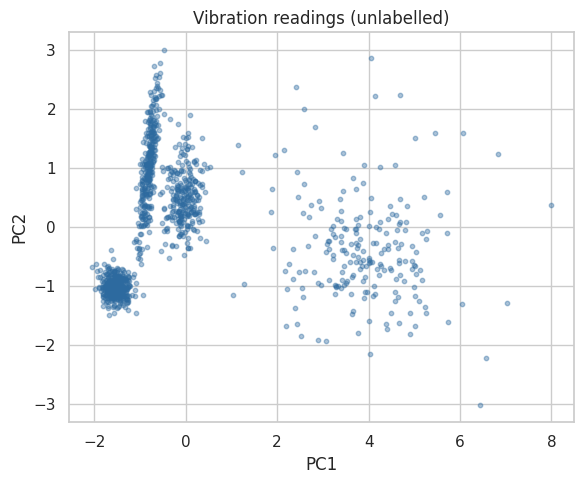

In [ ]:
import os
import numpy as np
import pandas as pd


def build_vibration(csv_path="vibration_signatures.csv", seed=182, verbose=False):
    """Vibration condition-monitoring signatures from rotating machinery — an UNLABELLED
    clustering dataset built for U18 Part 2 (hierarchical, DBSCAN, GMM).

    Designed so that:
      - fault families form clusters of DIFFERENT shape & density (GMM / DBSCAN shine,
        plain k-means struggles),
      - a sprinkling of scattered NOISE readings exist (DBSCAN should flag them as outliers),
      - features sit on different scales (scaling lesson carries over).

    Features (typical vibration-analysis descriptors):
      rms_mm_s          overall vibration energy (mm/s)
      peak_g            peak acceleration (g)
      crest_factor      peak / rms  (impulsiveness)
      kurtosis          spikiness of the waveform
      dom_freq_orders   dominant frequency as a multiple of running speed (1x, 2x, ...)
      hf_energy_pct     % energy in the high-frequency band (bearing tones)
    No label column — the fault regime is what clustering should reveal.
    """
    rng = np.random.default_rng(seed)

    def blob(n, mu, sd, shape=None):
        X = rng.normal(0, 1, size=(n, len(mu)))
        if shape is not None:        # elongate / correlate to make it non-spherical
            X = X @ shape
        return X * sd + mu

    # fault families (rms, peak_g, crest, kurt, dom_freq_orders, hf_energy_pct)
    healthy = blob(360, [1.4, 0.3, 3.0, 3.0, 1.0, 8],  [0.3, 0.08, 0.4, 0.4, 0.05, 2])
    # imbalance: strong 1x, low crest, fairly tight, ELONGATED along rms
    imbalance = blob(300, [5.0, 1.0, 3.2, 3.1, 1.0, 10],
                     [1.4, 0.2, 0.3, 0.3, 0.04, 3],
                     shape=np.diag([1.0, 0.3, 0.3, 0.3, 0.3, 0.6]))
    # misalignment: 2x dominant, moderate
    misalign = blob(260, [4.2, 1.2, 3.8, 3.6, 2.0, 14], [0.8, 0.25, 0.5, 0.5, 0.06, 3])
    # bearing defect: high crest/kurtosis, high-frequency energy, sparse & spread (low density)
    bearing = blob(150, [3.2, 2.6, 6.5, 8.0, 4.5, 45], [0.9, 0.7, 1.3, 2.2, 1.2, 12])

    X = np.vstack([healthy, imbalance, misalign, bearing])

    # scattered noise readings (sensor glitches / transient events) -> DBSCAN should call these noise
    lo = X.min(0); hi = X.max(0)
    noise = rng.uniform(lo, hi, size=(60, X.shape[1]))
    X = np.vstack([X, noise])
    rng.shuffle(X)

    cols = ["rms_mm_s", "peak_g", "crest_factor", "kurtosis", "dom_freq_orders", "hf_energy_pct"]
    df = pd.DataFrame(X, columns=cols).clip(lower=0)
    df["dom_freq_orders"] = df["dom_freq_orders"].round(2)
    df = df.round(3)
    df.to_csv(csv_path, index=False)
    if verbose:
        print("vibration:", df.shape)
        print("feature ranges:\n", (df.max() - df.min()).round(1).to_string())
        print("(4 fault families of differing shape/density + ~60 scattered noise rows; no labels)")
    return df

if not os.path.exists('vibration_signatures.csv'):
    build_vibration(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
df = pd.read_csv('vibration_signatures.csv')
X = StandardScaler().fit_transform(df.values)   # scale first — distance-based methods
P2 = PCA(n_components=2).fit_transform(X)        # 2-D view for plotting
print('readings:', df.shape)
df.head(3)


# Quick look at the raw structure in 2-D (no labels yet)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P2[:, 0], P2[:, 1], s=10, alpha=0.4, color='#2D6A9F')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('Vibration readings (unlabelled)')
plt.tight_layout(); plt.show()


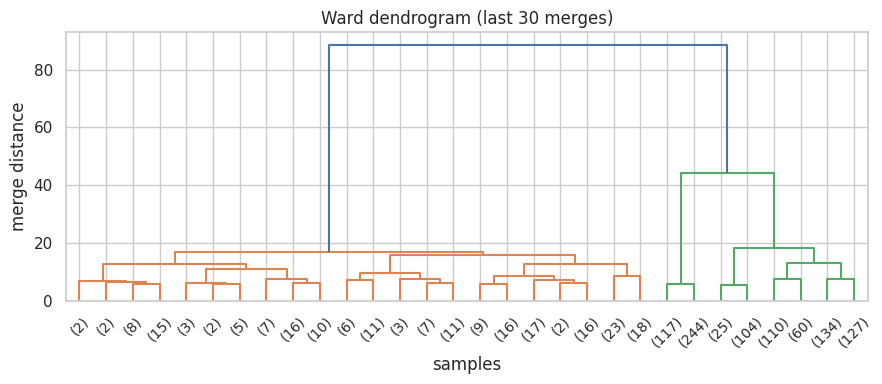

Tall vertical jumps = natural places to cut. Cutting gives clusters without pre-picking k.
cluster sizes: [209 361 129 431]


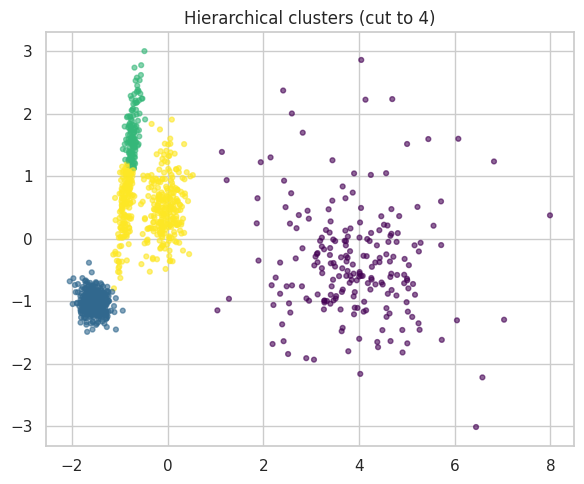

In [ ]:
# -----------------------------------------------------------
# 🔹 1A. BUILD A DENDROGRAM (Ward linkage)
# -----------------------------------------------------------
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
Z = linkage(X, method='ward')
fig, ax = plt.subplots(figsize=(9, 4))
dendrogram(Z, truncate_mode='lastp', p=30, ax=ax, color_threshold=0.7 * max(Z[:, 2]))
ax.set_title('Ward dendrogram (last 30 merges)'); ax.set_xlabel('samples'); ax.set_ylabel('merge distance')
plt.tight_layout(); plt.show()
print('Tall vertical jumps = natural places to cut. Cutting gives clusters without pre-picking k.')


# -----------------------------------------------------------
# 🔹 1B. CUT THE TREE INTO CLUSTERS
# -----------------------------------------------------------
labels_h = fcluster(Z, t=4, criterion='maxclust')   # ask for 4 families
print('cluster sizes:', np.bincount(labels_h)[1:])
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P2[:, 0], P2[:, 1], c=labels_h, cmap='viridis', s=12, alpha=0.6)
ax.set_title('Hierarchical clusters (cut to 4)'); plt.tight_layout(); plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster
import numpy as np

# 1. Build linkage matrices
Z_single = linkage(X, method='single')
Z_complete = linkage(X, method='complete')

# 2. Cut each into 4 clusters
labels_single = fcluster(Z_single, t=4, criterion='maxclust')
labels_complete = fcluster(Z_complete, t=4, criterion='maxclust')

# Print cluster sizes
print("Single Linkage Cluster Sizes:")
unique, counts = np.unique(labels_single, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c}")

print("\nComplete Linkage Cluster Sizes:")
unique, counts = np.unique(labels_complete, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c}")

Single Linkage Cluster Sizes:
Cluster 1: 1127
Cluster 2: 1
Cluster 3: 1
Cluster 4: 1

Complete Linkage Cluster Sizes:
Cluster 1: 110
Cluster 2: 934
Cluster 3: 62
Cluster 4: 24


DBSCAN found 4 clusters and flagged 169 noise points (label = -1).


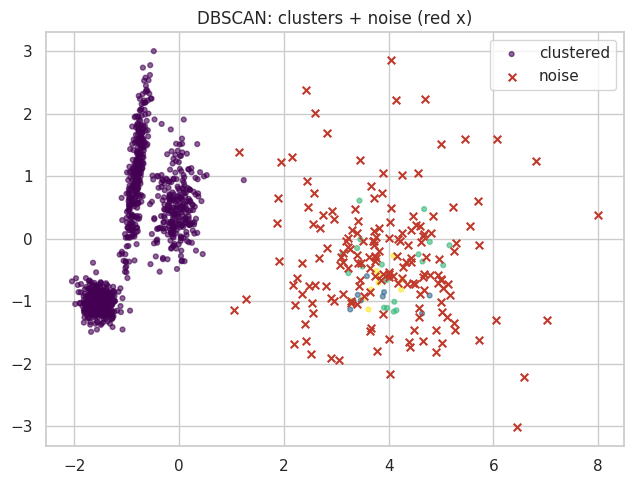

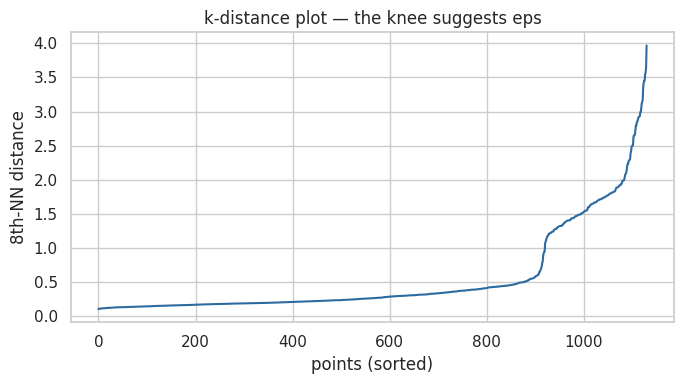

The elbow/knee height is a good first guess for eps.


In [ ]:

# -----------------------------------------------------------
# 🔹 2A. DBSCAN FINDS DENSE REGIONS AND LABELS THE REST AS NOISE
# -----------------------------------------------------------
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=1.2, min_samples=8).fit(X)
lab = db.labels_
n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
n_noise = int((lab == -1).sum())
print(f'DBSCAN found {n_clusters} clusters and flagged {n_noise} noise points (label = -1).')
fig, ax = plt.subplots(figsize=(6.5, 5))
mask = lab == -1
ax.scatter(P2[~mask, 0], P2[~mask, 1], c=lab[~mask], cmap='viridis', s=12, alpha=0.6, label='clustered')
ax.scatter(P2[mask, 0], P2[mask, 1], c='#C0392B', s=30, marker='x', label='noise')
ax.legend(); ax.set_title('DBSCAN: clusters + noise (red x)'); plt.tight_layout(); plt.show()


# -----------------------------------------------------------
# 🔹 2B. CHOOSING eps — THE k-DISTANCE PLOT
# -----------------------------------------------------------
from sklearn.neighbors import NearestNeighbors
k = 8
dist, _ = NearestNeighbors(n_neighbors=k).fit(X).kneighbors(X)
kd = np.sort(dist[:, k - 1])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(kd, color='#2D6A9F'); ax.set_xlabel('points (sorted)'); ax.set_ylabel(f'{k}th-NN distance')
ax.set_title('k-distance plot — the knee suggests eps'); plt.tight_layout(); plt.show()
print('The elbow/knee height is a good first guess for eps.')

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

# 1-2. Sweep eps values; report clusters and noise
eps_values = [0.8, 1.2, 1.8]

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=8)
    labels = db.fit_predict(X)

    # Number of clusters (excluding noise)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Number of noise points
    noise_count = np.sum(labels == -1)

    print(f"eps = {eps}")
    print(f"Clusters: {n_clusters}")
    print(f"Noise points: {noise_count}\n")

eps = 0.8
Clusters: 1
Noise points: 212

eps = 1.2
Clusters: 4
Noise points: 169

eps = 1.8
Clusters: 1
Noise points: 36



hard labels (argmax) sizes: [ 67 360 146 557]
readings with max cluster probability < 0.6 (ambiguous): 11


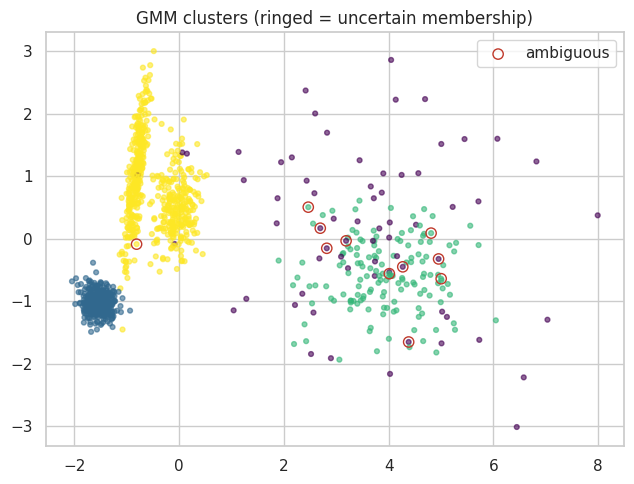

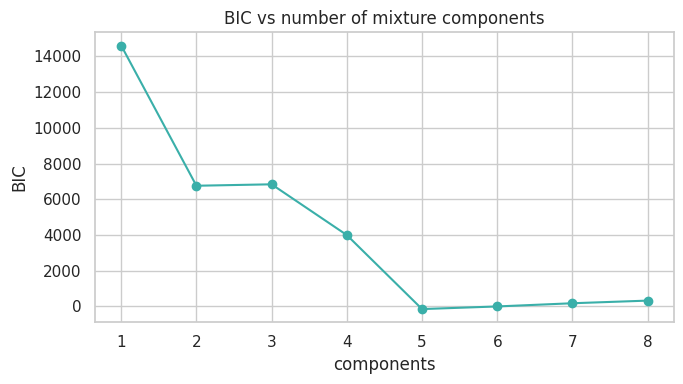

best #components by BIC: 5


In [ ]:

# -----------------------------------------------------------
# 🔹 3A. GMM GIVES EACH POINT A PROBABILITY PER CLUSTER
# -----------------------------------------------------------
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=0).fit(X)
labels_g = gmm.predict(X)
proba = gmm.predict_proba(X)
print('hard labels (argmax) sizes:', np.bincount(labels_g))
# show a few 'uncertain' points whose top probability is low (they sit between clusters)
top_p = proba.max(axis=1)
print('readings with max cluster probability < 0.6 (ambiguous):', int((top_p < 0.6).sum()))
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(P2[:, 0], P2[:, 1], c=labels_g, cmap='viridis', s=12, alpha=0.6)
amb = top_p < 0.6
ax.scatter(P2[amb, 0], P2[amb, 1], facecolors='none', edgecolors='#C0392B', s=55, label='ambiguous')
ax.legend(); ax.set_title('GMM clusters (ringed = uncertain membership)'); plt.tight_layout(); plt.show()


# -----------------------------------------------------------
# 🔹 3B. HOW MANY COMPONENTS? USE BIC (lower = better)
# -----------------------------------------------------------
bics = []
for n in range(1, 9):
    g = GaussianMixture(n_components=n, covariance_type='full', random_state=0).fit(X)
    bics.append(g.bic(X))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 9), bics, 'o-', color='#3AAFA9'); ax.set_xlabel('components'); ax.set_ylabel('BIC')
ax.set_title('BIC vs number of mixture components'); plt.tight_layout(); plt.show()
print('best #components by BIC:', int(np.argmin(bics) + 1))

In [ ]:
import numpy as np

# 1. Five most ambiguous readings + their probability vectors

probs = gmm.predict_proba(X)

max_probs = probs.max(axis=1)
ambiguous_idx = np.argsort(max_probs)[:5]

print("Five most ambiguous readings:\n")
for idx in ambiguous_idx:
    print(f"Reading {idx}:")
    print("Probability vector:", probs[idx])
    print("Max probability:", max_probs[idx])
    print()

Five most ambiguous readings:

Reading 148:
Probability vector: [5.35316029e-001 0.00000000e+000 4.64683971e-001 7.29953879e-140]
Max probability: 0.5353160289132496

Reading 979:
Probability vector: [4.60919714e-001 0.00000000e+000 5.39080286e-001 9.79350697e-121]
Max probability: 0.5390802862969714

Reading 639:
Probability vector: [5.42193174e-001 0.00000000e+000 4.57806826e-001 5.96810310e-116]
Max probability: 0.5421931743251824

Reading 403:
Probability vector: [4.54650497e-001 0.00000000e+000 5.45349503e-001 4.56216860e-105]
Max probability: 0.5453495031126285

Reading 92:
Probability vector: [5.46126434e-001 0.00000000e+000 4.53873566e-001 2.72064541e-103]
Max probability: 0.5461264339239342



In [ ]:
# -----------------------------------------------------------
# 🔹 4A. SILHOUETTE OF k-MEANS vs DBSCAN vs GMM
# -----------------------------------------------------------
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
km = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(X)
def safe_sil(labels):
    m = labels != -1   # silhouette ignores noise points
    if len(set(labels[m])) < 2: return float('nan')
    return silhouette_score(X[m], labels[m])
print('k-means silhouette:', round(safe_sil(km), 3))
print('DBSCAN  silhouette:', round(safe_sil(db.labels_), 3), '(noise excluded)')
print('GMM     silhouette:', round(safe_sil(labels_g), 3))



k-means silhouette: 0.5
DBSCAN  silhouette: nan (noise excluded)
GMM     silhouette: 0.497


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN # Import DBSCAN here

# 1. Comparison table

# Re-run DBSCAN with eps=1.2 to get labels with multiple clusters for silhouette score
db_for_sil = DBSCAN(eps=1.2, min_samples=8).fit(X)
dbscan_labels_for_silhouette = db_for_sil.labels_

comparison = pd.DataFrame({
    "Model": ["K-Means", "Ward", "DBSCAN", "Gaussian Mixture"],
    "#Clusters": [
        len(np.unique(km)),
        len(np.unique(labels_h)),
        len(set(dbscan_labels_for_silhouette)) - (1 if -1 in dbscan_labels_for_silhouette else 0),
        len(np.unique(labels_g))
    ],
    "Silhouette": [
        round(silhouette_score(X, km), 3),
        round(silhouette_score(X, labels_h), 3),
        round(silhouette_score(X[dbscan_labels_for_silhouette != -1],
                               dbscan_labels_for_silhouette[dbscan_labels_for_silhouette != -1]), 3),
        round(silhouette_score(X, labels_g), 3)
    ],
    "Handles Noise?": ["No", "No", "Yes", "No"]
})

print(comparison)

              Model  #Clusters  Silhouette Handles Noise?
0           K-Means          4       0.500             No
1              Ward          4       0.443             No
2            DBSCAN          4       0.665            Yes
3  Gaussian Mixture          4       0.497             No


In [ ]:
import pandas as pd

# 1. Profile DBSCAN clusters (exclude noise label -1)

# Make a copy of the original dataframe
df_profile = df.copy()

# Add DBSCAN cluster labels
df_profile["Cluster"] = dbscan_labels_for_silhouette

# Exclude noise points (Cluster = -1) and compute mean feature values
cluster_means = (
    df_profile[df_profile["Cluster"] != -1]
    .groupby("Cluster")
    .mean(numeric_only=True)
)

print("Mean feature values for each DBSCAN cluster:")
print(cluster_means)

Mean feature values for each DBSCAN cluster:
         rms_mm_s    peak_g  crest_factor  kurtosis  dom_freq_orders  \
Cluster                                                                
0        3.360376  0.788309      3.300042  3.192107         1.284653   
1        2.740778  2.017778      5.645000  7.590000         5.328889   
2        2.981500  3.084600      5.862050  8.847650         4.352000   
3        2.819400  2.372600      7.471300  6.493900         4.034000   

         hf_energy_pct  
Cluster                 
0            10.311124  
1            49.093889  
2            39.876500  
3            45.078800  


In [ ]:
import pandas as pd

# 1. Profile DBSCAN clusters (exclude noise label -1)

# Make a copy of the original dataframe
df_profile = df.copy()

# Add DBSCAN cluster labels
df_profile["Cluster"] = dbscan_labels_for_silhouette

# Exclude noise points (Cluster = -1) and compute mean feature values
cluster_means = (
    df_profile[df_profile["Cluster"] != -1]
    .groupby("Cluster")
    .mean(numeric_only=True)
)

print("Mean feature values for each DBSCAN cluster:")
print(cluster_means)

Mean feature values for each DBSCAN cluster:
         rms_mm_s    peak_g  crest_factor  kurtosis  dom_freq_orders  \
Cluster                                                                
0        3.360376  0.788309      3.300042  3.192107         1.284653   
1        2.740778  2.017778      5.645000  7.590000         5.328889   
2        2.981500  3.084600      5.862050  8.847650         4.352000   
3        2.819400  2.372600      7.471300  6.493900         4.034000   

         hf_energy_pct  
Cluster                 
0            10.311124  
1            49.093889  
2            39.876500  
3            45.078800  
